# exp-intragenic-architecture-eb-01

## 목적
같은 유전자 안의 복수 mutation 구조를 train-only Empirical-Bayes class score로 보존합니다. H0의 구조·파라미터·자동 specialist·0.80/0.20 결합은 바꾸지 않습니다. `42/777/2024` 3-seed를 한 번에 실행해 명확히 채택/종료합니다.

## 규칙
- 고정 암종명·유전자·exact mutation 목록을 사용하지 않습니다.
- vocabulary, EB, 표준화는 각 outer-fold train에서만 fit합니다.
- test.csv를 읽지 않고 train/test를 결합하지 않습니다. WT/blank/NaN은 event가 아닙니다.
- 통과: 세 seed 모두 상승, 평균 delta ≥ +0.008, 15 folds 중 11개 이상 상승.


In [1]:
from pathlib import Path
import gc, json, subprocess, sys
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
BASE = ROOT / 'experiments' / 'gs' / 'notebooks' / 'exp_model_006'
RUNNER = BASE / 'common' / 'run_intragenic_architecture_eb.py'
RESULT = BASE / 'result'
RUN_ID = 'exp-intragenic-architecture-eb-01'
SEEDS = (42, 777, 2024)
RUN_EXPERIMENT = True
assert (ROOT / 'data' / 'raw' / 'train.csv').exists() and RUNNER.exists()
print({'runner': RUNNER, 'result_dir': RESULT, 'seeds': SEEDS})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_006/common/run_intragenic_architecture_eb.py'), 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_006/result'), 'seeds': (42, 777, 2024)}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Smoke test
전체 CV 전에 schema, parser, test 미열람 계약을 확인합니다.

In [2]:
smoke = subprocess.run([sys.executable, str(RUNNER), '--smoke'], text=True, capture_output=True)
print(smoke.stdout)
if smoke.returncode: raise RuntimeError(smoke.stderr)
assert 'test_read' in smoke.stdout.lower()
assert 'nan_as_mutation_count' in smoke.stdout.lower()

{"smoke": "ok", "test_read": false, "nan_as_mutation_count": 0, "fixed_class_gene_mutation_rules": false}



## 2. Run 3-seed CV
H0를 seed별로 재현하므로 장시간 실행됩니다. 진행률은 seed/fold 단위로 출력됩니다.

In [3]:
if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), '--run-id', RUN_ID, '--seeds', *map(str, SEEDS)]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='architecture EB 3-seed', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-150:]
    if process.wait(): raise RuntimeError('Architecture EB runner failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 결과 파일만 읽습니다.')

architecture EB 3-seed: 1line [00:04,  4.70s/line]

[architecture-eb] train-only architecture token cache


architecture EB 3-seed: 2line [00:16,  8.86s/line]

[architecture-eb] seed 42, outer fold 1/5: H0 and architecture-EB


architecture EB 3-seed: 3line [05:58, 161.05s/line]

...

architecture EB 3-seed: 16line [1:34:09, 386.34s/line]

[architecture-eb] seed 2024, outer fold 5/5: H0 and architecture-EB


architecture EB 3-seed: 17line [1:39:57, 374.63s/line]

{"seeds": [42, 777, 2024], "test_read": false, "train_test_concat": false, "fixed_class_gene_mutation_rules": false, "leakage_check": true, "nan_as_mutation_count": 0, "positive_fold_count": 6, "mean_fold_delta": -0.002435470345172271, "all_seed_delta_positive": false, "decision": "rejected_or_not_detected", "seed_audits": [{"seed": 42, "outer_splits": 5, "architecture_eb_inner_splits": 5, "test_read": false, "train_test_concat": false, "fixed_class_gene_mutation_rules": false, "architecture_vocabulary_source": "outer_fold_train_only", "leakage_check": true, "nan_as_mutation_count": 0, "runtime_seconds": 1969.2220714999712, "decision": "rejected", "delta_vs_h0": -0.0017957539701387581, "positive_fold_count": 2}, {"seed": 777, "outer_splits": 5, "architecture_eb_inner_splits": 5, "test_read": false, "train_test_concat": false, "fixed_class_gene_mutation_rules": false, "architecture_vocabulary_source": "outer_fold_train_only", "leakage_check": true, "nan_as_mutation_count": 0, "runtime_s

architecture EB 3-seed: 17line [1:39:57, 352.81s/line]


## 3. 결과와 계약 확인

In [4]:
seed_summary = pd.read_csv(RESULT / f'{RUN_ID}_seed_summary.csv')
summary_3seed = pd.read_csv(RESULT / f'{RUN_ID}_3seed_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_fold_metrics.csv')
classes = pd.read_csv(RESULT / f'{RUN_ID}_class_metrics.csv')
audit = json.loads((RESULT / f'{RUN_ID}_leakage_audit.json').read_text())
assert seed_summary.leakage_check.all() and seed_summary.nan_as_mutation_count.eq(0).all()
assert audit['test_read'] is False and audit['train_test_concat'] is False
display(seed_summary.sort_values(['seed','variant']))
display(summary_3seed)
print(json.dumps(audit, ensure_ascii=False, indent=2))

,seed,variant,oof_macro_f1,oof_accuracy,feature_count,convergence_warning_count,leakage_check,nan_as_mutation_count,delta_vs_h0
0,42,H0,0.544744,0.555556,8193.2,0,True,0,0.000000
1,42,H0_intragenic_architecture_EB,0.542948,0.554910,8219.2,0,True,0,-0.001796
2,777,H0,0.538710,0.551685,8188.4,0,True,0,0.000000
3,777,H0_intragenic_architecture_EB,0.537393,0.551363,8214.4,0,True,0,-0.001317
4,2024,H0,0.544306,0.556201,8193.0,0,True,0,0.000000
5,2024,H0_intragenic_architecture_EB,0.542168,0.553459,8219.0,0,True,0,-0.002138


,variant,seed_count,oof_macro_f1_mean,oof_macro_f1_std,delta_vs_h0_mean,delta_vs_h0_std,convergence_warning_count,leakage_check,nan_as_mutation_count
0,H0,3,0.542587,0.003365,0.00000,0.000000,0,True,0
1,H0_intragenic_architecture_EB,3,0.540836,0.003008,-0.00175,0.000412,0,True,0


{
  "seeds": [
    42,
    777,
    2024
  ],
  "test_read": false,
  "train_test_concat": false,
  "fixed_class_gene_mutation_rules": false,
  "leakage_check": true,
  "nan_as_mutation_count": 0,
  "positive_fold_count": 6,
  "mean_fold_delta": -0.002435470345172271,
  "all_seed_delta_positive": false,
  "decision": "rejected_or_not_detected",
  "seed_audits": [
    {
      "seed": 42,
      "outer_splits": 5,
      "architecture_eb_inner_splits": 5,
      "test_read": false,
      "train_test_concat": false,
      "fixed_class_gene_mutation_rules": false,
      "architecture_vocabulary_source": "outer_fold_train_only",
      "leakage_check": true,
      "nan_as_mutation_count": 0,
      "runtime_seconds": 1969.2220714999712,
      "decision": "rejected",
      "delta_vs_h0": -0.0017957539701387581,
      "positive_fold_count": 2
    },
    {
      "seed": 777,
      "outer_splits": 5,
      "architecture_eb_inner_splits": 5,
      "test_read": false,
      "train_test_concat": false,

## 4. Paired score / class F1 시각화

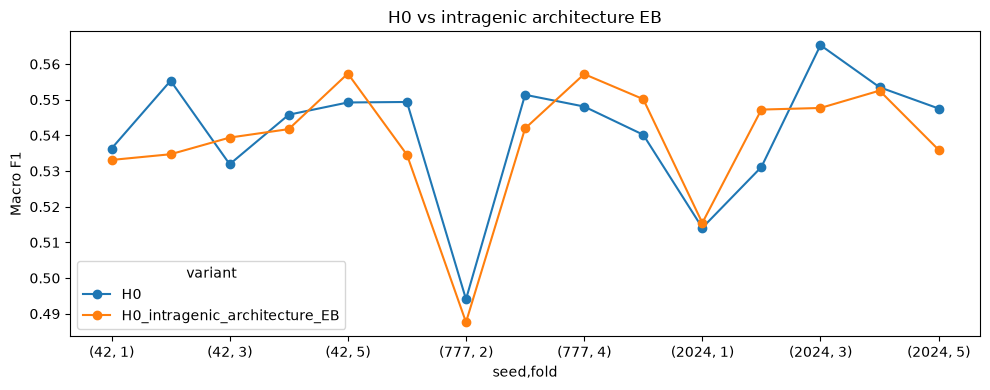

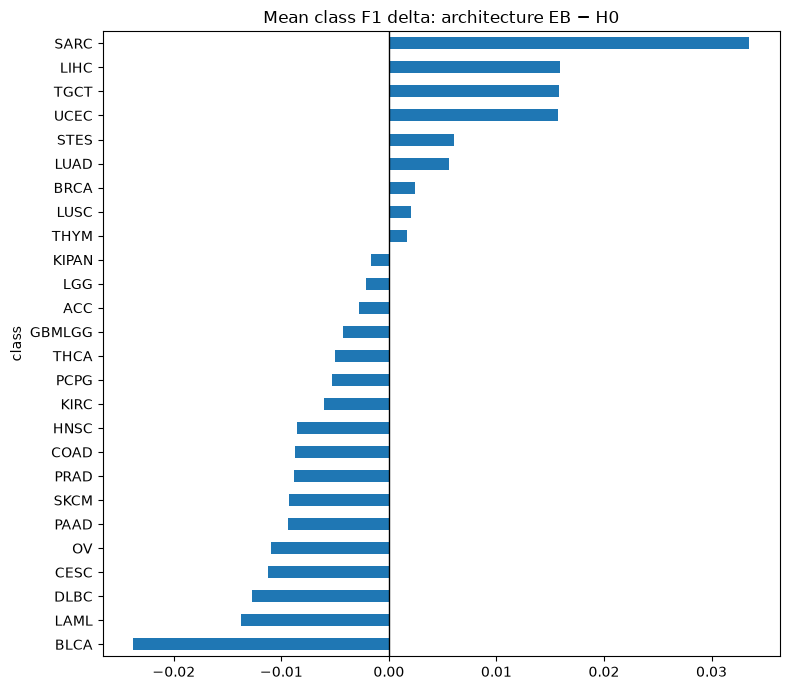

In [5]:
pivot = folds.pivot_table(index=['seed','fold'], columns='variant', values='macro_f1').sort_index()
ax = pivot.plot(marker='o', figsize=(10,4), title='H0 vs intragenic architecture EB')
ax.set_ylabel('Macro F1'); plt.tight_layout(); plt.show()

class_delta = classes.groupby('class').delta.mean().sort_values()
ax = class_delta.plot.barh(figsize=(8,7), title='Mean class F1 delta: architecture EB − H0')
ax.axvline(0, color='black', linewidth=1); plt.tight_layout(); plt.show()

## 5. 자동 판정
승격 기준을 통과하지 못하면 이 축은 종료합니다.

In [6]:
candidate = seed_summary.query("variant == 'H0_intragenic_architecture_EB'").set_index('seed').oof_macro_f1
baseline = seed_summary.query("variant == 'H0'").set_index('seed').oof_macro_f1
print('seed deltas:', (candidate - baseline).to_dict())
print('positive folds:', audit['positive_fold_count'], '/ 15')
print('AUTO DECISION:', audit['decision'])
gc.collect()

seed deltas: {42: -0.0017957539701387581, 777: -0.0013172410510211563, 2024: -0.0021380388987127796}
positive folds: 6 / 15
AUTO DECISION: rejected_or_not_detected


3285